### Task 3: Load the Dataset and Handle Missing Values

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/penguins.csv')

# Display basic info and identify missing values
print("Dataset Info:")
print(df.info())

# Find rows missing all four measurements
measure_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
missing_all_measures = df[df[measure_cols].isnull().all(axis=1)]
print(f"\nPenguins missing all four measurements ({len(missing_all_measures)} rows):")
display(missing_all_measures)

# Find rows missing sex
missing_sex = df[df['sex'].isnull()]
print(f"\nPenguins missing 'sex' ({len(missing_sex)} rows):")
display(missing_sex)

# Decision: Drop the 2 rows missing all measurements since they carry no physical data.
# For the rows missing 'sex', we will keep them for overall distribution plots,
# but they will naturally be excluded or grouped as 'NaN' when splitting by 'sex'.
df_clean = df.dropna(subset=measure_cols).copy()
print(f"\nDataset size after dropping rows missing all measurements: {df_clean.shape}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

Penguins missing all four measurements (2 rows):


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN



Penguins missing 'sex' (11 rows):


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN



Dataset size after dropping rows missing all measurements: (342, 7)


### 1. Distribution of Body Mass
We'll plot the overall distribution of body mass to observe its shape.

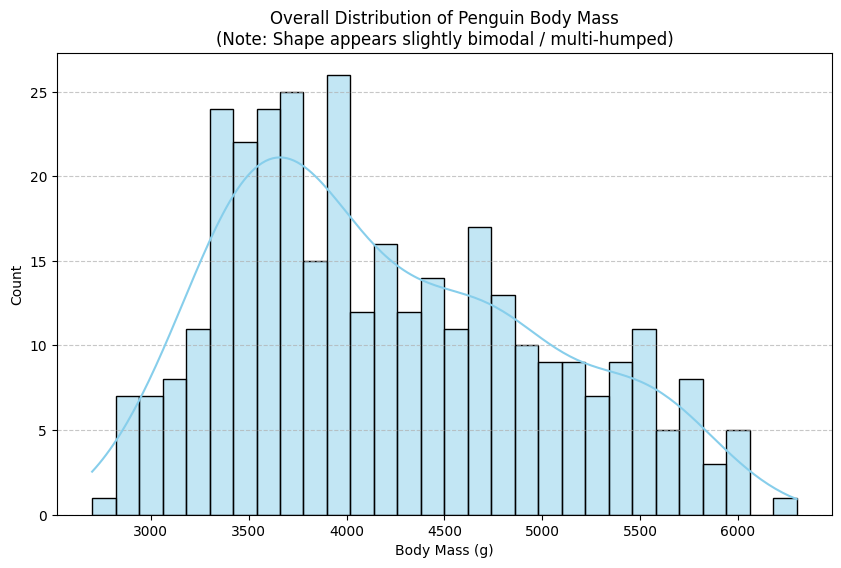

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='body_mass_g', kde=True, bins=30, color='skyblue')
plt.title('Overall Distribution of Penguin Body Mass\n(Note: Shape appears slightly bimodal / multi-humped)')
plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Body Mass Distribution Split by Species
Let's see if splitting by species explains the multiple humps in the overall distribution.

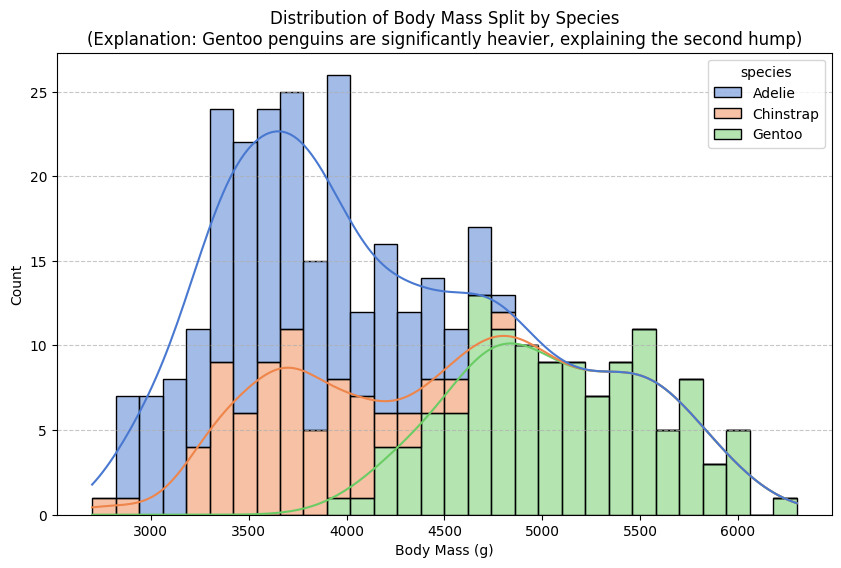

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='body_mass_g', hue='species', kde=True, bins=30, multiple='stack', palette='muted')
plt.title('Distribution of Body Mass Split by Species\n(Explanation: Gentoo penguins are significantly heavier, explaining the second hump)')
plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Scatter Plot: Bill Length vs Bill Depth (Simpson's Paradox)
We'll visualize the relationship between bill length and bill depth overall versus within each species.

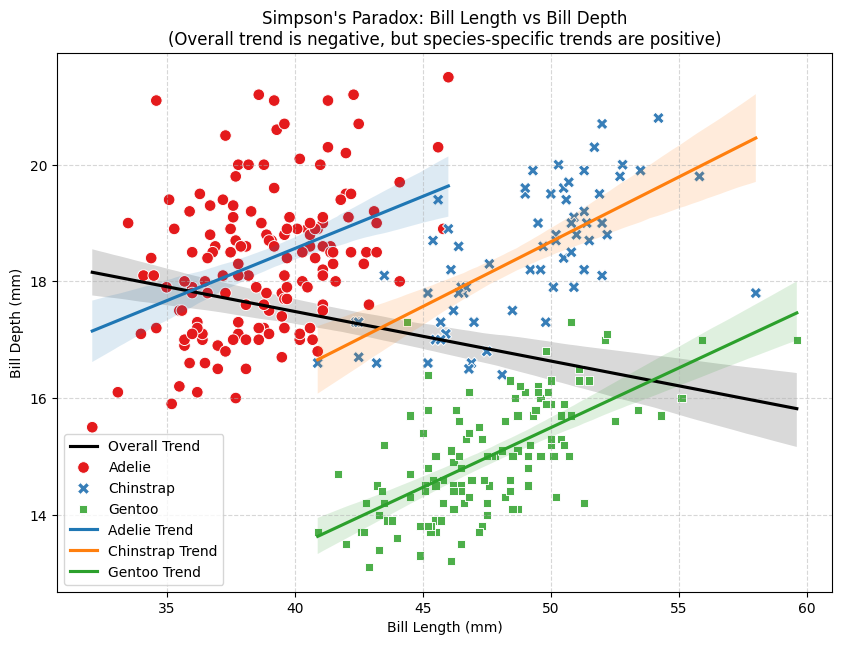

In [14]:
plt.figure(figsize=(10, 7))
# Draw overall regression line (negative trend)
sns.regplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', scatter=False, color='black', label='Overall Trend')
# Draw scatter plot and regression lines split by species (positive trends)
sns.scatterplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', hue='species', style='species', s=70, palette='Set1')
for species, group in df_clean.groupby('species'):
    sns.regplot(data=group, x='bill_length_mm', y='bill_depth_mm', scatter=False, label=f'{species} Trend')

plt.title("Simpson's Paradox: Bill Length vs Bill Depth\n(Overall trend is negative, but species-specific trends are positive)")
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Explanation of Simpson's Paradox
Across all species, we observe a negative correlation because Adelie penguins have short, deep bills, while Gentoo penguins have long, shallow bills. When grouped together, this cluster separation creates a misleading negative slope. However, within any single species, a longer bill naturally correlates with a deeper bill, resulting in a positive slope. This demonstrates why analyzing subgroups individually is crucial.

### 4. Average Body Mass Across Species and Sex
Finally, let's compare the average body mass across species and sex.

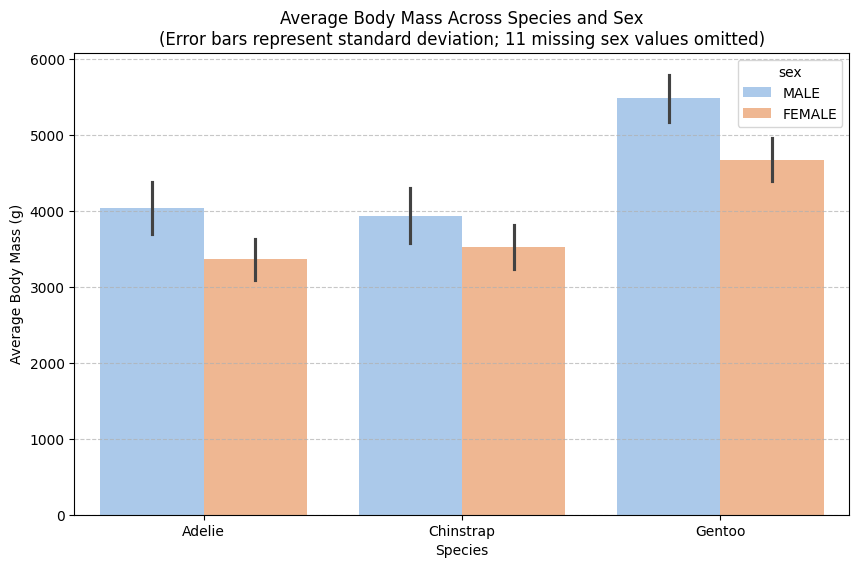

In [15]:
# Drop rows where sex is missing for this specific visualization
df_sex_clean = df_clean.dropna(subset=['sex'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_sex_clean, x='species', y='body_mass_g', hue='sex', palette='pastel', errorbar='sd')
plt.title('Average Body Mass Across Species and Sex\n(Error bars represent standard deviation; 11 missing sex values omitted)')
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()